<a href="https://colab.research.google.com/github/Nagata2442/Analisis_sentimen_Arsenal_vs_Real_Madrid_UCL/blob/main/Analisis_sentimen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tweet-preprocessor
!pip install textblob
!pip install wordcloud
!pip install nltk
!pip install -U deep-translator
!pip install Sastrawi
import nltk
nltk.download('punkt_tab')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import Sastrawi
import time
import preprocessor as p

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/analisis/arsenal_vs_realmadrid.csv",
    encoding="latin1"
)

In [ ]:
# 2. Bersihkan header: hilangkan _hanya_ trailing semicolon (;)
df.columns = (
    df.columns
      .astype(str)
      .str.strip()              # buang spasi di ujung
      .str.replace(r";+$", "", regex=True)  # buang semua ';' di akhir tiap nama kolom
)

# 3. Pastikan nama kolom sekarang benar
print("Columns after clean:", df.columns.tolist())
#    … seharusnya 'username' ada di daftar, bukan 'username;;;;'

# 4. Bersihkan nilai di kolom username
#    Jika ada semicolon yang menempel di tiap nilai, buang juga
df["username"] = (
    df["username"]
      .astype(str)
      .str.rstrip(";")     # buang semua ';' di ujung tiap string
)

# 5. Cek hasil
print(df[["username"]].head())


Columns after clean: ['conversation_id_str', 'created_at', 'favorite_count', 'full_text', 'id_str', 'image_url', 'in_reply_to_screen_name', 'lang', 'location', 'quote_count', 'reply_count', 'retweet_count', 'tweet_url', 'user_id_str', 'username']
         username
0          lahhnm
1     azikri_alif
2   SeputarMadrid
3  ChelseafanIndo
4           vtocx


In [ ]:
display(df)

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1912651181006156143,Wed Apr 16 23:59:54 +0000 2025,0,@idextratime Langsung saja saat adik mbappe ke...,1912657234775142809,NaN,idextratime,in,NaN,0,1,0,https://x.com/lahhnm/status/1912657234775142809,458330204,lahhnm
1,1912614169268170978,Wed Apr 16 23:59:46 +0000 2025,1,@my_supersoccer Di tambah kondisi Arsenal yang...,1912657199052276102,NaN,my_supersoccer,in,NaN,0,0,0,https://x.com/azikri_alif/status/1912657199052...,1875376455959588864,azikri_alif
2,1912657167020355668,Wed Apr 16 23:59:38 +0000 2025,45,Thibaut Courtois pasca laga Real Madrid 1-2 Ar...,1912657167020355668,https://pbs.twimg.com/media/GosfjQwacAENjwU.jpg,NaN,in,NaN,0,1,3,https://x.com/SeputarMadrid/status/19126571670...,473090819,SeputarMadrid
3,1912657023784874048,Wed Apr 16 23:59:04 +0000 2025,71,Perlu kita apresiasi dan kasih selamat untuk @...,1912657023784874048,https://pbs.twimg.com/media/GosfbL-bIAArVAD.jpg,NaN,in,NaN,0,3,2,https://x.com/ChelseafanIndo/status/1912657023...,498594244,ChelseafanIndo
4,1912656998627455282,Wed Apr 16 23:58:58 +0000 2025,0,mari ketemu arsenal lagi di final ucl.,1912656998627455282,NaN,NaN,in,NaN,0,0,0,https://x.com/vtocx/status/1912656998627455282,1880821437902299136,vtocx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3414,1909946754948125087,Wed Apr 09 12:29:26 +0000 2025,0,Wamumbi alitoa matamshi makali dhidi ya Gachag...,1909946758576120265,NaN,LibraNewsonline,in,NaN,0,0,0,https://x.com/LibraNewsonline/status/190994675...,1846240037534683137,LibraNewsonline
3415,1909875223488561380,Wed Apr 09 07:45:11 +0000 2025,0,Myles Lewis Skelly elite LB. Posisi MLS di LB ...,1909875223488561380,NaN,NaN,in,NaN,0,0,0,https://x.com/yourmissingone/status/1909875223...,2661578551,yourmissingone
3416,1909870773239792094,Wed Apr 09 07:44:15 +0000 2025,1,@Gooners_Report min sejak ada rumor nico willi...,1909874989601636553,NaN,Gooners_Report,in,NaN,0,0,0,https://x.com/mallimunogen/status/190987498960...,1086597166427037697,mallimunogen
3417,1909698184919892254,Wed Apr 09 07:17:09 +0000 2025,0,@Jo_Ks7 @tirta_cipeng @IDGoonerscom Itu keren ...,1909868167402602630,NaN,Jo_Ks7,in,NaN,0,0,0,https://x.com/Nhagi77/status/1909868167402602630,1125652501196181506,Nhagi77


In [ ]:
df_subset = df[["full_text", "username", "created_at"]]
print(df_subset.head())


                                           full_text        username  \
0  @idextratime Langsung saja saat adik mbappe ke...          lahhnm   
1  @my_supersoccer Di tambah kondisi Arsenal yang...     azikri_alif   
2  Thibaut Courtois pasca laga Real Madrid 1-2 Ar...   SeputarMadrid   
3  Perlu kita apresiasi dan kasih selamat untuk @...  ChelseafanIndo   
4             mari ketemu arsenal lagi di final ucl.           vtocx   

                       created_at  
0  Wed Apr 16 23:59:54 +0000 2025  
1  Wed Apr 16 23:59:46 +0000 2025  
2  Wed Apr 16 23:59:38 +0000 2025  
3  Wed Apr 16 23:59:04 +0000 2025  
4  Wed Apr 16 23:58:58 +0000 2025  


In [ ]:
df = df[['full_text', 'username','created_at']]
df

,full_text,username,created_at
0,@idextratime Langsung saja saat adik mbappe ke...,lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,@my_supersoccer Di tambah kondisi Arsenal yang...,azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,Thibaut Courtois pasca laga Real Madrid 1-2 Ar...,SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,Perlu kita apresiasi dan kasih selamat untuk @...,ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,mari ketemu arsenal lagi di final ucl.,vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3414,Wamumbi alitoa matamshi makali dhidi ya Gachag...,LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3415,Myles Lewis Skelly elite LB. Posisi MLS di LB ...,yourmissingone,Wed Apr 09 07:45:11 +0000 2025
3416,@Gooners_Report min sejak ada rumor nico willi...,mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,@Jo_Ks7 @tirta_cipeng @IDGoonerscom Itu keren ...,Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
df.shape

(3419, 3)

In [ ]:
df = df.drop_duplicates(subset=['full_text'])

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
full_text,0
username,0
created_at,0


In [ ]:
df.shape

(3204, 3)

In [ ]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', ' ', text) #penghapusan terhadap mention
    text = re.sub(r'#\w+',' ', text) #penghapusan terhadap hashtag
    text = re.sub(r'RT[\s]+',' ',text) #penghapusan terhadap retweet
    text = re.sub(r'https?://\S+',' ', text) #penghapusan url

    text = re.sub(r'[^A-Za-z0-9 ]', ' ', text) #penghapusan karakter non alfanumerik
    text = re.sub(r'\s+', ' ',text).strip() #penghapusan spasi berlebih

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [ ]:
df['full_text'] = df['full_text'].str.lower()

In [ ]:
df

,full_text,username,created_at
0,langsung saja saat adik mbappe ke arsenal aja ...,lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,di tambah kondisi arsenal yang tidak punya str...,azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,thibaut courtois pasca laga real madrid 1 2 ar...,SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,perlu kita apresiasi dan kasih selamat untuk a...,ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,mari ketemu arsenal lagi di final ucl,vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3413,ruang di belakang rodrygo bellingham dieksploi...,kevinbahasbola,Thu Apr 10 01:05:10 +0000 2025
3414,wamumbi alitoa matamshi makali dhidi ya gachag...,LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3416,min sejak ada rumor nico williams ke arsenal d...,mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,itu keren sih serangan arsenal sering banget l...,Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
# 1. Kamus normalisasi
norm = {
    "gw": "saya", "gua": "saya", "gue": "saya", "lu": "kamu", "lo": "kamu",
    "gk": "tidak", "ga": "tidak", "sdh": "sudah", "dpt": "dapat", "blg": "bilang",
    "jgn": "jangan", "kalo": "kalau", "ko": "kok", "klo": "kalau", "bsa": "bisa",
    "jd": "jadi", "santuy": "santai", "tdk": "tidak", "mmg": "memang", "memng": "memang",
    "dgn": "dengan", "udh": "sudah", "blm": "belum", "tp": "tapi", "tpi": "tapi",
    "gak": "tidak", "krn": "karena", "bgt": "banget", "sm": "sama", "org": "orang",
    "knp": "kenapa", "dr": "dari", "dri" : "dari", "doank": "saja", "doang": "saja",
    "psg": "", "liverpool": "", "manchester united": "", "barca": "", "dortmund": "",
    "inter milan": "", "bayern munchen": "", "bayern": "", "city": "", "wkwk": "",
    "d": "di", "trs": "terus", "emang": "memang", "yaudh": "yaudah", "pd": "pada",
    "dlm": "dalam", "cmn": "hanya", "km": "kamu", "ksh": "kasih", "gpp": "tidak apa-apa",
    "td": "tadi", "jg": "juga", "engga": "tidak", "ky" : "kayak", "ttp" : "tetap",
    "thn" : "tahun", "ajg" : "anjing", "jing" : "anjing", "slalu" : "selalu", "btul" : "betul",
    "apalgi" : "apa lagi", "aplgi" : "apa lagi", "palagi" : "apa lagi", "aplg" : "apa lagi",
    "anj" : "anjing", "kmk" : "kimak"
}

# 2. Siapkan pattern regex dengan boundary yang ketat
#    Urutkan kunci berdasarkan panjang (descending) supaya multi-kata
keys_sorted = sorted((re.escape(k) for k in norm), key=len, reverse=True)
pattern = re.compile(
    r"(?<!\w)(" + "|".join(keys_sorted) + r")(?!\w)",
    flags=re.IGNORECASE
)

# 3. Fungsi normalisasi
def normalisasi(text: str) -> str:
    def repl(m):
        # ambil group, ubah ke lowercase untuk lookup
        key = m.group(0).lower()
        return norm.get(key, m.group(0))
    return pattern.sub(repl, text)

df['full_text'] = df['full_text'].apply(lambda x: normalisasi(x))
df

,full_text,username,created_at
0,langsung saja saat adik mbappe ke arsenal aja ...,lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,di tambah kondisi arsenal yang tidak punya str...,azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,thibaut courtois pasca laga real madrid 1 2 ar...,SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,perlu kita apresiasi dan kasih selamat untuk a...,ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,mari ketemu arsenal lagi di final ucl,vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3413,ruang di belakang rodrygo bellingham dieksploi...,kevinbahasbola,Thu Apr 10 01:05:10 +0000 2025
3414,wamumbi alitoa matamshi makali dhidi ya gachag...,LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3416,min sejak ada rumor nico williams ke arsenal d...,mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,itu keren sih serangan arsenal sering banget l...,Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary
more_stop_words = ["tidak", "si", "yang", "dan", "di", "ke", "dari", "adalah", "untuk"] #membuang kata tidak berbobot

# Ambil daftar stopword bawaan lalu tambahkan
factory = StopWordRemoverFactory()
stop_words = factory.get_stop_words()
stop_words.extend(more_stop_words)

# Inisialisasi StopWordRemover baru
dictionary = ArrayDictionary(stop_words)
stopword_remover = StopWordRemover(dictionary)

# Terapkan ke kolom full_text yang sudah ada
df['full_text'] = df['full_text'].astype(str).apply(lambda x: stopword_remover.remove(x))

df

,full_text,username,created_at
0,langsung adik mbappe arsenal aja ikutin jejak ...,lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,tambah kondisi arsenal punya striker king ucl ...,azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,thibaut courtois pasca laga real madrid 1 2 ar...,SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,perlu apresiasi kasih selamat atas keberhasila...,ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,ketemu arsenal final ucl,vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3413,ruang belakang rodrygo bellingham dieksploitas...,kevinbahasbola,Thu Apr 10 01:05:10 +0000 2025
3414,wamumbi alitoa matamshi makali dhidi gachagua ...,LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3416,min sejak rumor nico williams arsenal martinel...,mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,keren sih serangan arsenal sering banget lewat...,Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
df['full_text'] = df['full_text'].apply(lambda x: x.split())

In [ ]:
df

,full_text,username,created_at
0,"[langsung, adik, mbappe, arsenal, aja, ikutin,...",lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,"[tambah, kondisi, arsenal, punya, striker, kin...",azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,"[thibaut, courtois, pasca, laga, real, madrid,...",SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,"[perlu, apresiasi, kasih, selamat, atas, keber...",ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,"[ketemu, arsenal, final, ucl]",vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3413,"[ruang, belakang, rodrygo, bellingham, diekspl...",kevinbahasbola,Thu Apr 10 01:05:10 +0000 2025
3414,"[wamumbi, alitoa, matamshi, makali, dhidi, gac...",LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3416,"[min, sejak, rumor, nico, williams, arsenal, m...",mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,"[keren, sih, serangan, arsenal, sering, banget...",Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
df

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(token_list):
    stemmed_words = []
    for word in token_list:  #langsung iterasi item dalam list
        stemmed_word = stemmer.stem(word)
        stemmed_words.append(stemmed_word)
    return stemmed_words #Return list dalam stemming

tokenized = tokenized.apply(stemming)

tokenized.to_csv("/content/drive/MyDrive/analisis/Preprocessing_arsenalvsrealmadrid.csv", index=False)

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/analisis/Preprocessing_arsenalvsrealmadrid.csv", encoding= 'latin1')
data.head()

,full_text
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja..."
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str..."
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real..."
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at..."
4,"['ketemu', 'arsenal', 'final', 'ucl']"


In [ ]:
df

,full_text,username,created_at
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja...",lahhnm,Wed Apr 16 23:59:54 +0000 2025
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str...",azikri_alif,Wed Apr 16 23:59:46 +0000 2025
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real...",SeputarMadrid,Wed Apr 16 23:59:38 +0000 2025
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at...",ChelseafanIndo,Wed Apr 16 23:59:04 +0000 2025
4,"['ketemu', 'arsenal', 'final', 'ucl']",vtocx,Wed Apr 16 23:58:58 +0000 2025
...,...,...,...
3413,"['ruang', 'belakang', 'rodrygo', 'bellingham',...",kevinbahasbola,Thu Apr 10 01:05:10 +0000 2025
3414,"['wamumbi', 'alitoa', 'matamshi', 'makali', 'd...",LibraNewsonline,Wed Apr 09 12:29:26 +0000 2025
3416,"['min', 'sejak', 'rumor', 'nico', 'williams', ...",mallimunogen,Wed Apr 09 07:44:15 +0000 2025
3417,"['keren', 'sih', 'serangan', 'arsenal', 'serin...",Nhagi77,Wed Apr 09 07:17:09 +0000 2025


In [ ]:
!pip install -U deep-translator
from deep_translator import GoogleTranslator

translated_texts = data['full_text'].apply(
    lambda x: GoogleTranslator(source='auto', target='en').translate(text=x)
)
data['translated'] = translated_texts

In [ ]:
data = pd.read_csv("/content/drive/MyDrive/analisis/Preprocessing_arsenalvsrealmadrid.csv", encoding='latin1')

# Tampilkan beberapa baris pertama untuk melihat struktur data
print("Data awal:")
print(data.head())
print(f"\nJumlah data: {len(data)}")

# Buat objek translator
translator = GoogleTranslator(source='auto', target='en')

# Fungsi untuk menerjemahkan teks dengan error handling
def translate_text(text):
    try:
        if pd.isna(text) or text == '':
            return text
        if len(str(text)) > 5000:
            text = str(text)[:5000]
        time.sleep(1)  # jeda 1 detik per terjemahan
        translated = translator.translate(str(text))
        return translated
    except Exception as e:
        print(f"Error translating: {text[:50]}... Error: {e}")
        return text  # Return original text jika gagal

# Terjemahkan kolom 'full_text' (sesuaikan nama kolom dengan dataset Anda)
print("\nMulai proses translate...")
data['full_text_translated'] = data['full_text'].apply(translate_text)

# Tampilkan hasil translate
print("\nHasil translate:")
for i in range(min(5, len(data))):
    print(f"\nOriginal: {data['full_text'].iloc[i]}")
    print(f"Translated: {data['full_text_translated'].iloc[i]}")
    print("-" * 50)

data.to_csv(
    r"/content/drive/MyDrive/analisis/Preprocessed_Translated.csv",
    index=False,
    encoding="utf-8"
)
print("Selesai.")

Data awal:
                                           full_text
0  ['langsung', 'adik', 'mbappe', 'arsenal', 'aja...
1  ['tambah', 'kondisi', 'arsenal', 'punya', 'str...
2  ['thibaut', 'courtois', 'pasca', 'laga', 'real...
3  ['perlu', 'apresiasi', 'kasih', 'selamat', 'at...
4              ['ketemu', 'arsenal', 'final', 'ucl']

Jumlah data: 3204

Mulai proses translate...

Hasil translate:

Original: ['langsung', 'adik', 'mbappe', 'arsenal', 'aja', 'ikutin', 'jejak', 'henry', 'inget', '1', 'piala', 'emas', 'liga', 'inggris', '20', 'ucl']
Translated: ['direct', 'younger brother', 'mbappe', 'arsenal', 'just', 'follow', 'trace', 'Henry', 'remember', '1', 'Cup', 'Gold', 'League', 'England', '20', 'UCL']
--------------------------------------------------

Original: ['tambah', 'kondisi', 'arsenal', 'punya', 'striker', 'king', 'ucl', 'malah', 'kalah']
Translated: ['added', 'condition', 'Arsenal', 'have', 'striker', 'king', 'ucl', 'instead', 'lost']
--------------------------------------------

In [ ]:
from textblob import Word

nltk.download('wordnet')

# Pastikan semua data bertipe string sebelum lemmatization
data['full_text_translated'] = data['full_text_translated'].astype(str).apply(
    lambda x: " ".join([Word(word).lemmatize() for word in x.split()])
)

df

In [ ]:
print(data[["full_text","full_text_translated"]].head())

                                           full_text  \
0  ['langsung', 'adik', 'mbappe', 'arsenal', 'aja...   
1  ['tambah', 'kondisi', 'arsenal', 'punya', 'str...   
2  ['thibaut', 'courtois', 'pasca', 'laga', 'real...   
3  ['perlu', 'apresiasi', 'kasih', 'selamat', 'at...   
4              ['ketemu', 'arsenal', 'final', 'ucl']   

                                full_text_translated  
0  ['direct', 'younger brother', 'mbappe', 'arsen...  
1  ['added', 'condition', 'Arsenal', 'have', 'str...  
2  ['Thibaut', 'Courtois', 'post', 'match', 'real...  
3  ['need', 'appreciation', 'love', 'congratulati...  
4                ['Meet', 'Arsenal', 'Final', 'UCL']  


In [ ]:
data

,full_text,full_text_translated
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja...","['direct', 'younger brother', 'mbappe', 'arsen..."
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str...","['added', 'condition', 'Arsenal', 'have', 'str..."
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real...","['Thibaut', 'Courtois', 'post', 'match', 'real..."
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at...","['need', 'appreciation', 'love', 'congratulati..."
4,"['ketemu', 'arsenal', 'final', 'ucl']","['Meet', 'Arsenal', 'Final', 'UCL']"
...,...,...
3199,"['ruang', 'belakang', 'rodrygobellingham', 'ek...","['space', 'back', 'Rodrygobellingham', 'exploi..."
3200,"['wamumbi', 'alitoa', 'matamshi', 'makali', 'd...","['Modes',' gave ',' pronunciation ',' edge ','..."
3201,"['min', 'sejak', 'rumor', 'nico', 'williams', ...","['Min', 'Since', 'Rumors', 'Nico', 'Williams',..."
3202,"['keren', 'sih', 'serang', 'arsenal', 'sering'...","['cool', 'any', 'attack', 'arsenal', 'often', ..."


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/analisis/Preprocessed_Translated.csv", encoding= 'latin1')
data

,full_text,full_text_translated
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja...","['direct', 'younger brother', 'mbappe', 'arsen..."
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str...","['added', 'condition', 'Arsenal', 'have', 'str..."
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real...","['Thibaut', 'Courtois', 'post', 'match', 'real..."
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at...","['need', 'appreciation', 'love', 'congratulati..."
4,"['ketemu', 'arsenal', 'final', 'ucl']","['Meet', 'Arsenal', 'Final', 'UCL']"
...,...,...
3199,"['ruang', 'belakang', 'rodrygobellingham', 'ek...","['space', 'back', 'Rodrygobellingham', 'exploi..."
3200,"['wamumbi', 'alitoa', 'matamshi', 'makali', 'd...","['Modes',' gave ',' pronunciation ',' edge ','..."
3201,"['min', 'sejak', 'rumor', 'nico', 'williams', ...","['Min', 'Since', 'Rumors', 'Nico', 'Williams',..."
3202,"['keren', 'sih', 'serang', 'arsenal', 'sering'...","['cool', 'any', 'attack', 'arsenal', 'often', ..."


In [ ]:
from textblob import TextBlob
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
tweets = data['full_text_translated'].fillna('')

# 2) Hitung polarity & label
scores = []
labels = []
for tweet in tweets:
    analysis = TextBlob(tweet)
    score = analysis.sentiment.polarity
    scores.append(score)
    if score > 0:
        labels.append('Positif')
    elif score == 0:
        labels.append('Netral')
    else:
        labels.append('Negatif')

# 3) Masukkan ke DataFrame
data['sentiment_score'] = scores
data['sentiment_label'] = labels

# 4) Print hasil ringkas
print("Distribusi label:\n", data['sentiment_label'].value_counts())
print(f"\nTotal tweet: {len(data)}")
data.to_csv(
    r"/content/drive/MyDrive/analisis/Translated_Sentiment.csv",
    index=False,
    encoding="utf-8"
)
print("Selesai.")

Distribusi label:
 sentiment_label
Positif    1547
Netral     1361
Negatif     296
Name: count, dtype: int64

Total tweet: 3204
Selesai.


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/analisis/Translated_Sentiment.csv", encoding= 'latin1')
data

,full_text,full_text_translated,sentiment_score,sentiment_label
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja...","['direct', 'younger brother', 'mbappe', 'arsen...",0.050000,Positif
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str...","['added', 'condition', 'Arsenal', 'have', 'str...",0.000000,Netral
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real...","['Thibaut', 'Courtois', 'post', 'match', 'real...",0.337500,Positif
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at...","['need', 'appreciation', 'love', 'congratulati...",0.433333,Positif
4,"['ketemu', 'arsenal', 'final', 'ucl']","['Meet', 'Arsenal', 'Final', 'UCL']",0.000000,Netral
...,...,...,...,...
3199,"['ruang', 'belakang', 'rodrygobellingham', 'ek...","['space', 'back', 'Rodrygobellingham', 'exploi...",-0.125000,Negatif
3200,"['wamumbi', 'alitoa', 'matamshi', 'makali', 'd...","['Modes',' gave ',' pronunciation ',' edge ','...",-0.300000,Negatif
3201,"['min', 'sejak', 'rumor', 'nico', 'williams', ...","['Min', 'Since', 'Rumors', 'Nico', 'Williams',...",0.166667,Positif
3202,"['keren', 'sih', 'serang', 'arsenal', 'sering'...","['cool', 'any', 'attack', 'arsenal', 'often', ...",0.305952,Positif


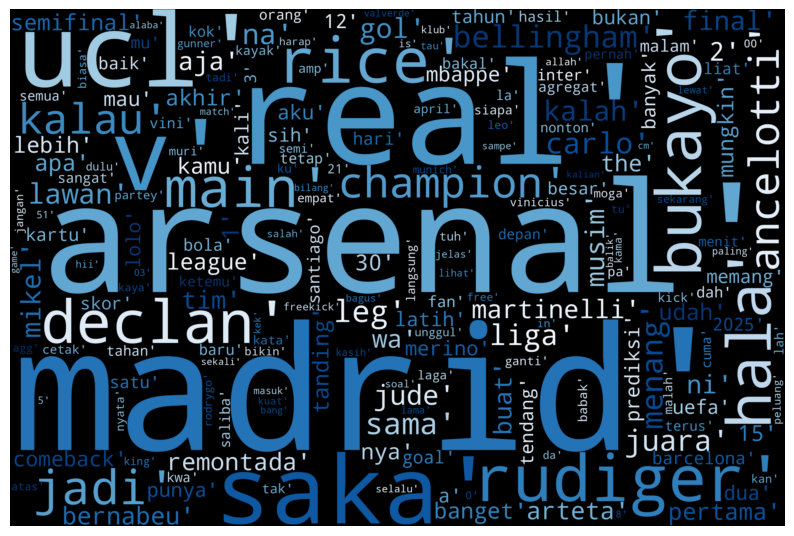

In [ ]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(wordcloud)

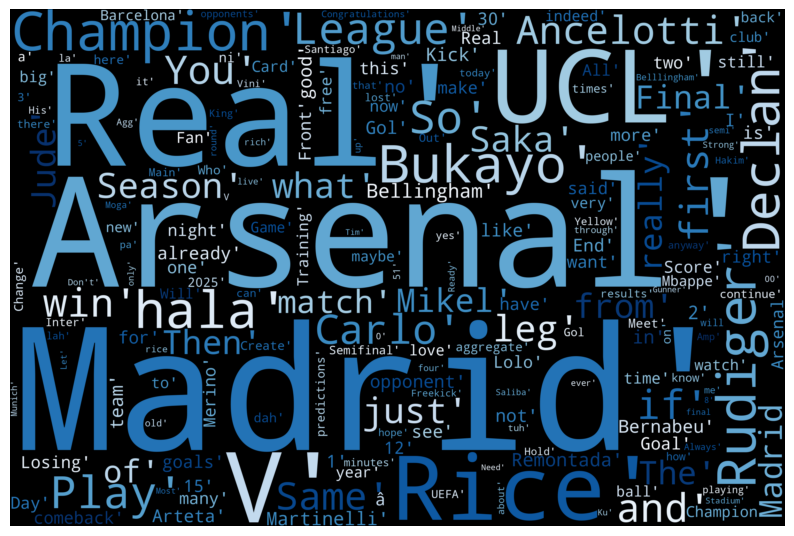

In [ ]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text_translated']])

wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(wordcloud)

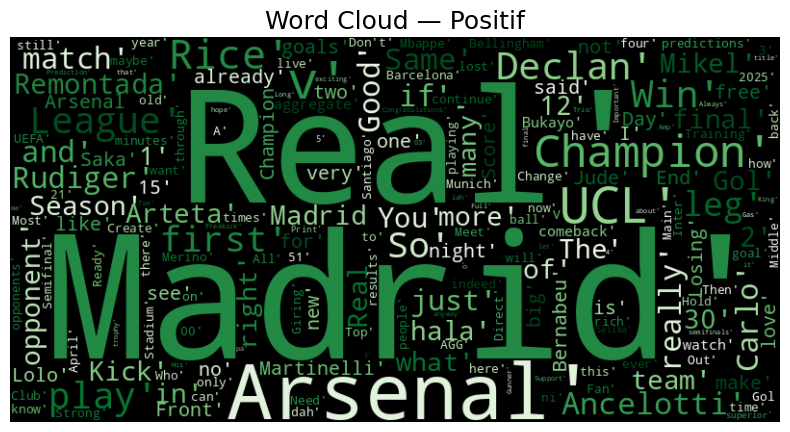

In [ ]:
# 1) Kumpulkan semua teks dengan label Positif
pos_text = ' '.join(
    data.loc[data['sentiment_label']=='Positif', 'full_text_translated']
)

# 2) Generate WordCloud
wc_pos = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Greens',
    stopwords=set(STOPWORDS),
    collocations=False
).generate(pos_text)

# 3) Plot
plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.title('Word Cloud — Positif', fontsize=18)
plt.axis('off')
plt.show()


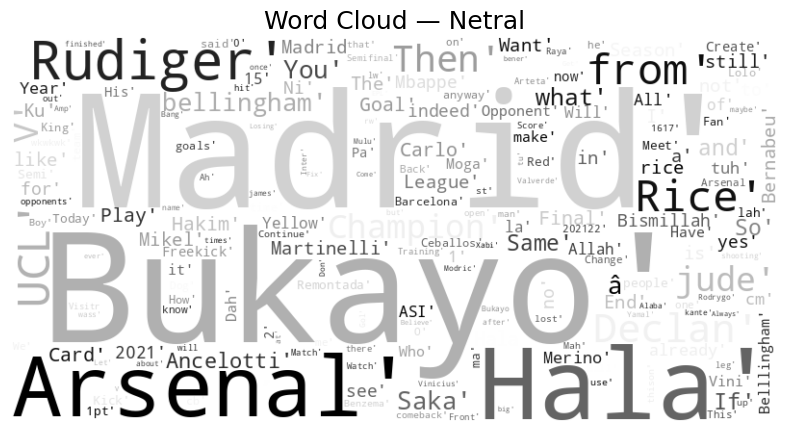

In [ ]:
# 1) Kumpulkan semua teks Netral
neu_text = " ".join(
    data.loc[data.sentiment_label=='Netral', 'full_text_translated']
)

# 2) Generate WordCloud
wc_neu = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='gray',
    stopwords=set(STOPWORDS),
    collocations=False
).generate(neu_text)

# 3) Plot hasil Netral
plt.figure(figsize=(10, 5))
plt.imshow(wc_neu, interpolation='bilinear')
plt.title('Word Cloud — Netral', fontsize=18)
plt.axis('off')
plt.show()

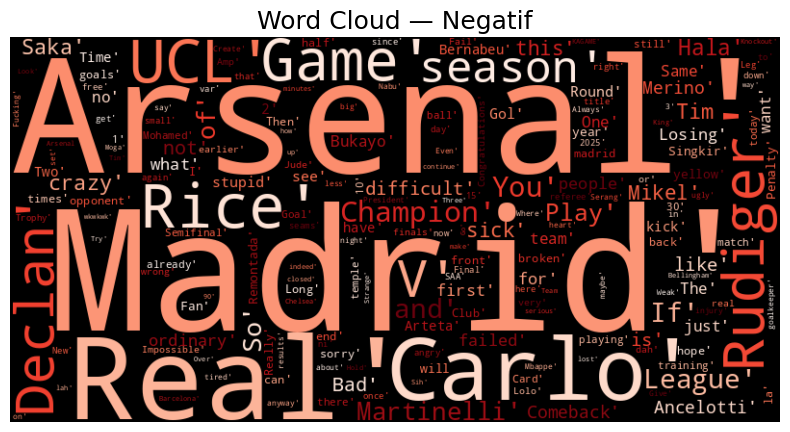

In [ ]:
# 1) Kumpulkan semua teks dengan label Negatif
neg_text = ' '.join(
    data.loc[data['sentiment_label']=='Negatif', 'full_text_translated']
)

# 2) Generate WordCloud
wc_neg = WordCloud(
    width=800, height=400,
    background_color='black',
    colormap='Reds',
    stopwords=set(STOPWORDS),
    collocations=False
).generate(neg_text)

# 3) Plot
plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.title('Word Cloud — Negatif', fontsize=18)
plt.axis('off')
plt.show()


/tmp/ipython-input-13-1910462892.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment_label',


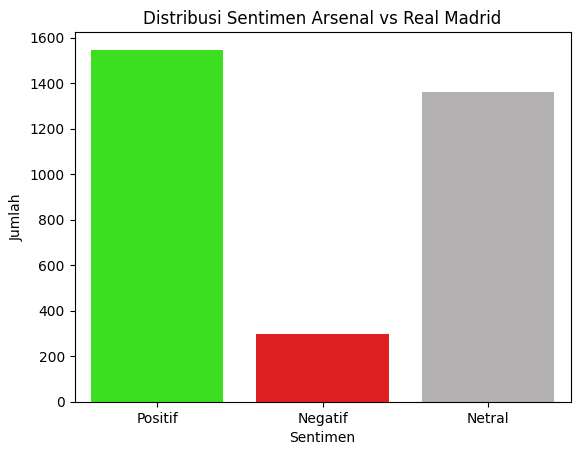

In [ ]:
sns.countplot(data=data, x='sentiment_label',
              order=['Positif','Negatif','Netral'],
              palette=['#24ff00','#ff0000','#b4b0b0'])
plt.title("Distribusi Sentimen Arsenal vs Real Madrid")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()


In [ ]:
data

,full_text,full_text_translated,sentiment_score,sentiment_label
0,"['langsung', 'adik', 'mbappe', 'arsenal', 'aja...","['direct', 'younger brother', 'mbappe', 'arsen...",0.050000,Positif
1,"['tambah', 'kondisi', 'arsenal', 'punya', 'str...","['added', 'condition', 'Arsenal', 'have', 'str...",0.000000,Netral
2,"['thibaut', 'courtois', 'pasca', 'laga', 'real...","['Thibaut', 'Courtois', 'post', 'match', 'real...",0.337500,Positif
3,"['perlu', 'apresiasi', 'kasih', 'selamat', 'at...","['need', 'appreciation', 'love', 'congratulati...",0.433333,Positif
4,"['ketemu', 'arsenal', 'final', 'ucl']","['Meet', 'Arsenal', 'Final', 'UCL']",0.000000,Netral
...,...,...,...,...
3199,"['ruang', 'belakang', 'rodrygobellingham', 'ek...","['space', 'back', 'Rodrygobellingham', 'exploi...",-0.125000,Negatif
3200,"['wamumbi', 'alitoa', 'matamshi', 'makali', 'd...","['Modes',' gave ',' pronunciation ',' edge ','...",-0.300000,Negatif
3201,"['min', 'sejak', 'rumor', 'nico', 'williams', ...","['Min', 'Since', 'Rumors', 'Nico', 'Williams',...",0.166667,Positif
3202,"['keren', 'sih', 'serang', 'arsenal', 'sering'...","['cool', 'any', 'attack', 'arsenal', 'often', ...",0.305952,Positif


In [ ]:
from sklearn.model_selection import train_test_split

# DataFrame dengan kolom 'full_text_translated' dan 'sentiment_label'
X = data['full_text_translated']
y = data['sentiment_label']

# Stratified split 50% train, 50% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    stratify=y,
    random_state=42
)

# Kembalikan jadi list-of-tuples jika memang perlu:
train_set = list(zip(X_train, y_train))

In [ ]:
from textblob.classifiers import NaiveBayesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1) Siapkan list (text, label)
X = data['full_text_translated'].fillna('').tolist()
y = data['sentiment_label'].tolist()

# 2) Split data (80% train, 20% test) dengan stratify agar proporsi label terjaga
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3) Latih TextBlob NB di train_set
train_set = list(zip(X_train, y_train))
cl = NaiveBayesClassifier(train_set)

# 4) Predict di test set
y_pred = [cl.classify(text) for text in X_test]

# 5) Cetak metrik evaluasi
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))
report_dict = classification_report(
    y_test, y_pred,
    labels=['Negatif','Netral','Positif'],
    output_dict=True,
    digits=3
)

# Ubah menjadi DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Tampilkan tabel
print("\nClassification Report (Tabel):")
print(report_df)

Naive Bayes Accuracy: 0.7800312012480499

Classification Report (Tabel):
              precision    recall  f1-score     support
Negatif        0.615385  0.135593  0.222222   59.000000
Netral         0.763578  0.878676  0.817094  272.000000
Positif        0.803175  0.816129  0.809600  310.000000
accuracy       0.780031  0.780031  0.780031    0.780031
macro avg      0.727379  0.610133  0.616305  641.000000
weighted avg   0.769088  0.780031  0.758716  641.000000


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes         import MultinomialNB
from sklearn.metrics             import log_loss

vect = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
results_nb = []

for test_size in [0.3, 0.2, 0.1]:
    # 1) split data
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )
    # 2) vectorize
    X_tr_tfidf = vect.fit_transform(X_tr)
    X_te_tfidf = vect.transform(X_te)
    # 3) train NB
    nb = MultinomialNB().fit(X_tr_tfidf, y_tr)
    # 4) prediksi & proba
    y_te_pred  = nb.predict(X_te_tfidf)
    y_te_proba = nb.predict_proba(X_te_tfidf)
    # 5) hitung metrik
    acc  = accuracy_score(y_te, y_te_pred)
    loss = log_loss(y_te, y_te_proba, labels=nb.classes_)
    results_nb.append({
        'Data Train(%)': int((1-test_size)*100),
        'Data Test(%)':  int(test_size*100),
        'Accuracy':      round(acc, 4),
        'Loss':          round(loss, 5)
    })

# tampilkan tabel
df_nb = pd.DataFrame(results_nb)
display(df_nb)

,Data Train(%),Data Test(%),Accuracy,Loss
0,70,30,0.6715,0.70694
1,80,20,0.6864,0.69426
2,90,10,0.6542,0.69395


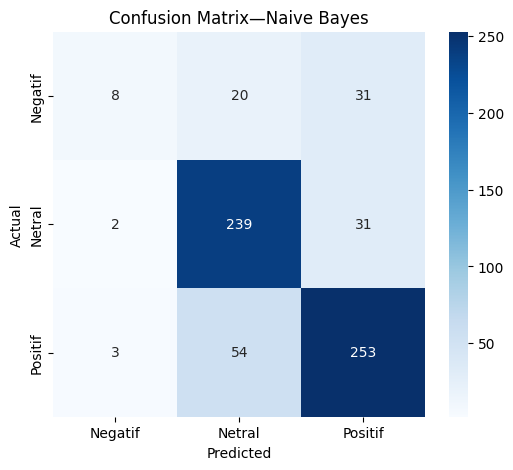

In [ ]:
# 1) Predict label test set dengan TextBlob NB
y_true = y_test
y_pred_nb = [cl.classify(text) for text in X_test]

# 2) Hitung confusion matrix
from sklearn.metrics   import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = ['Negatif','Netral','Positif']
cm = confusion_matrix(y_true, y_pred_nb, labels=labels)

# 3) Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix—Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# 1) SPLIT DATA + STRATIFY
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) VECTORIZE DENGAN TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
vect = TfidfVectorizer(
    max_features=5_000,
    ngram_range=(1,2),
    stop_words='english'  # atau list stopword Indo kalau perlu
)
X_tr = vect.fit_transform(X_train)
X_te = vect.transform(X_test)

# 3) TRAIN KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5,
    metric='cosine'       # jarak kosinus umum dipakai di teks
)
knn.fit(X_tr, y_train)

# 4) EVALUASI
from sklearn.metrics import accuracy_score, classification_report
y_pred = knn.predict(X_te)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
report_dict = classification_report(
    y_test, y_pred,
    labels=['Negatif','Netral','Positif'],
    output_dict=True,
    digits=3
)

# Ubah menjadi DataFrame
report_df = pd.DataFrame(report_dict).transpose()

# Tampilkan tabel
print("\nClassification Report (Tabel):")
print(report_df)

KNN Accuracy: 0.6645865834633385

Classification Report (Tabel):
              precision    recall  f1-score     support
Negatif        0.163265  0.135593  0.148148   59.000000
Netral         0.636646  0.753676  0.690236  272.000000
Positif        0.788889  0.687097  0.734483  310.000000
accuracy       0.664587  0.664587  0.664587    0.664587
macro avg      0.529600  0.525455  0.524289  641.000000
weighted avg   0.666702  0.664587  0.661739  641.000000


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss
results = []

for test_size in [0.3, 0.2, 0.1]:
    # Split data secara stratified
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=42
    )

    # Vectorize
    X_tr_tfidf = vect.fit_transform(X_tr)
    X_te_tfidf = vect.transform(X_te)

    # Train KNN
    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(X_tr_tfidf, y_tr)

    # Evaluasi
    acc = accuracy_score(y_te, knn.predict(X_te_tfidf))
    loss = log_loss(y_te, knn.predict_proba(X_te_tfidf))

    results.append({
        'Data Train(%)': int((1-test_size)*100),
        'Data Test(%)': int(test_size*100),
        'Accuracy': round(acc, 4),
        'Loss': round(loss, 5)
    })

# Buat DataFrame dan tampilkan
df_results = pd.DataFrame(results)
display(df_results)

,Data Train(%),Data Test(%),Accuracy,Loss
0,70,30,0.6570,3.38971
1,80,20,0.6646,3.30947
2,90,10,0.6511,2.97997


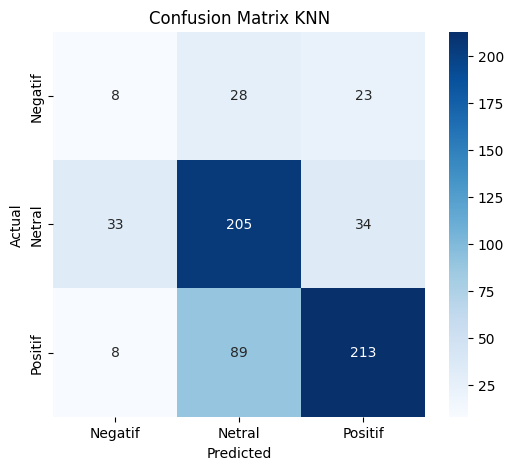

In [ ]:
# Plot Confusion Matrix untuk KNN
from sklearn.metrics   import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Hitung confusion matrix
#    Jika kamu sudah define knn.classes_, bisa dipakai langsung:
labels = knn.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 2) Visualisasikan dengan heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels
)
plt.title("Confusion Matrix KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()